In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.cluster import KMeans
from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score
from xgboost import XGBClassifier
from sklearn.svm import SVC

In [108]:
df = pd.read_csv("/Users/hakanzip/Desktop/Machine_Learning/ırıs_saksuka/data/Iris.csv")
df.head(15)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


Tek object veri var onun tipini değiştiricez. Kısa bir çalışma olacak. Toplam 150 sütun varmış. ID 'de bilgi içermediği için genelde silinir zaten.

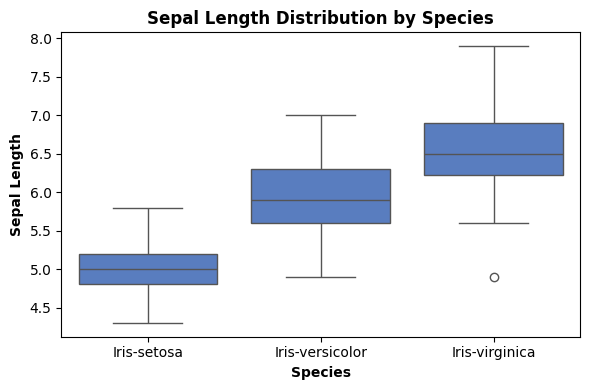

In [110]:
plt.figure(figsize=(6, 4))
sns.set_palette("muted")
sns.boxplot(x='Species', y='SepalLengthCm', data=df)
plt.title('Sepal Length Distribution by Species', fontweight='bold')
plt.xlabel('Species', fontweight='bold')
plt.ylabel('Sepal Length', fontweight='bold')
plt.tight_layout()
plt.savefig('sepal_length_boxplot.png')
plt.show()

Bu grafik, Iris türlerinin çanak yaprağı uzunluklarını gösteriyor. Iris-setosa türü, ortalama 5 santimetre ile en kısa yapraklara sahip, genellikle 4.8-5.2 santimetre arasında. Iris-versicolor 5.6-6.3 santimetre arasında değişirken, Iris-virginica ortalama 6.5 santimetre ile en uzun yapraklara sahip, 6.2-6.9 santimetre aralığında. Her türün uzunluk aralığı bu görselde belirgin şekilde ayrılıyor.

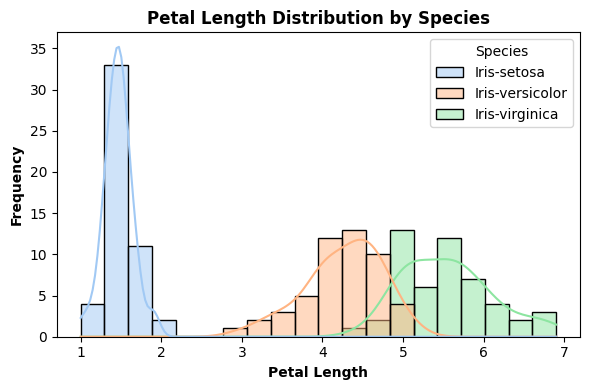

In [111]:
plt.figure(figsize=(6, 4))
sns.set_palette("pastel")
sns.histplot(data=df, x='PetalLengthCm', hue='Species', kde=True, bins=20)
plt.title('Petal Length Distribution by Species', fontweight='bold')
plt.xlabel('Petal Length', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.tight_layout()
plt.savefig('petal_length_histogram.png')
plt.show()

Bu grafik, Iris türlerinin taç yaprağı uzunluklarını frekanslarıyla gösteriyor. Iris-setosa'nın taç yaprakları kısa, çoğu 1.0-2.0 santimetre arasında yoğunlaşmış durumda. Iris-versicolor 3.0-5.0 santimetre arasında daha geniş bir dağılım sergilerken, Iris-virginica'nın taç yaprakları en uzun, 4.5-7.0 santimetreye uzanıyor. Her türün uzunlukları belirgin şekilde farklılaşıyor.

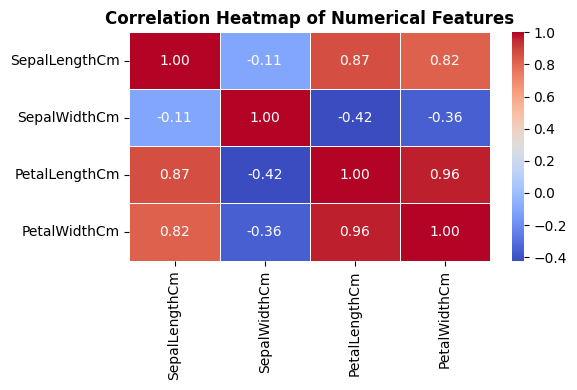

In [112]:
plt.figure(figsize=(6, 4))
sns.set_palette("deep")
corr = df.drop(columns=['Id', 'Species']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

Bu ısı haritası, sayısal özellikler arası ilişkileri gösteriyor. Taç yaprağı uzunluğu ve genişliği arasında 0.96 ile çok güçlü pozitif bir ilişki var. Çanak yaprağı uzunluğu da taç yaprağı uzunluğu 0.87 ve genişliği 0.82 ile güçlü pozitif korelasyonlar gösteriyor. Çanak yaprağı genişliği ise diğer özelliklerle zayıf veya negatif ilişkide.

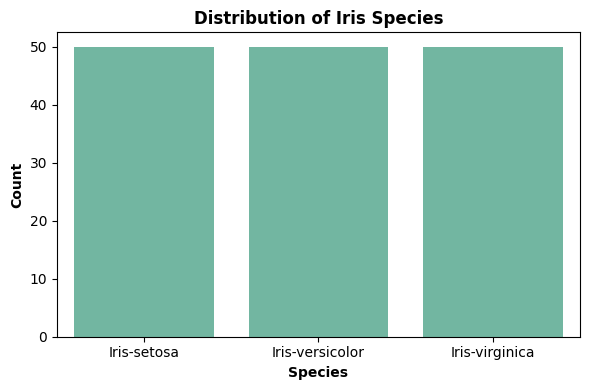

In [113]:
plt.figure(figsize=(6, 4))
sns.set_palette("Set2")
sns.countplot(x='Species', data=df)
plt.title('Distribution of Iris Species', fontweight='bold')
plt.xlabel('Species', fontweight='bold')
plt.ylabel('Count', fontweight='bold')
plt.tight_layout()
plt.savefig('species_distribution.png')
plt.show()

Bu grafik, veri setindeki Iris türlerinin dağılımını açıkça gösteriyor. Görüldüğü üzere, Iris-setosa, Iris-versicolor ve Iris-virginica olmak üzere her üç tür de eşit sayıda örneklem içeriyor. Her bir Iris türünden tam 50 adet veri noktası bulunuyor. Bu durum, kullanılan veri setinin türler arasında son derece dengeli bir dağılıma sahip olduğunu ortaya koyuyor.

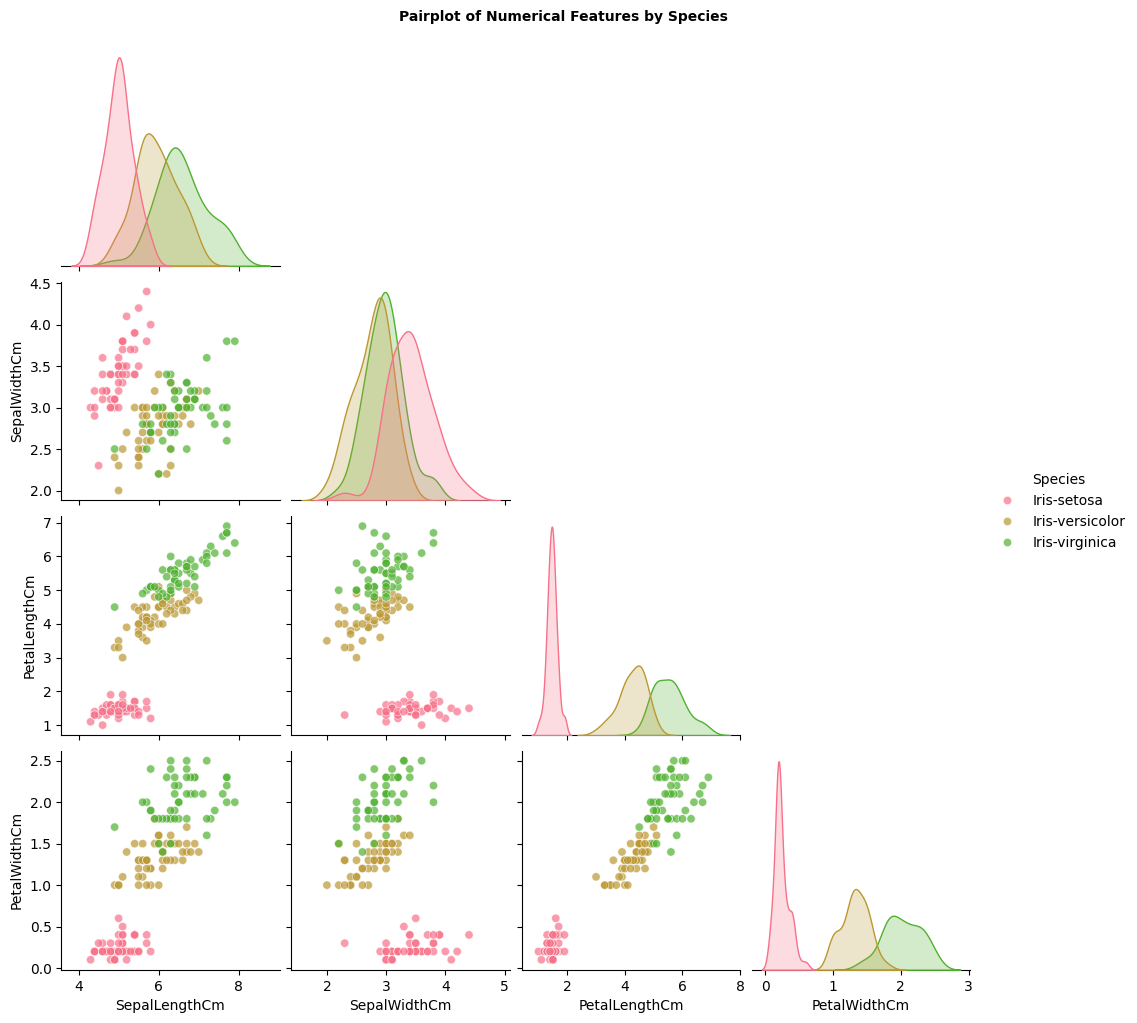

In [114]:
sns.set_palette("husl")
sns.pairplot(df.drop(columns='Id'), hue='Species', corner=True, diag_kind='kde', plot_kws={'alpha': 0.7})
plt.suptitle('Pairplot of Numerical Features by Species', fontweight='bold', fontsize=10, y=1.02)
plt.savefig('pairplot_species.png')
plt.show()

Bu grafik, Iris türlerinin tüm sayısal özellikler arasındaki ilişkilerini ve dağılımlarını sergiliyor. Iris-setosa, özellikle taç yaprağı uzunluğu ve genişliği açısından diğer türlerden açıkça ayrılıyor. Iris-versicolor ve Iris-virginica, çanak yaprağı özelliklerinde bir miktar örtüşse de, taç yaprağı boyutlarında daha belirgin bir ayrım gösteriyor. Bu görsel, her türün farklı bir boyut profiline sahip olduğunu ortaya koyuyor.

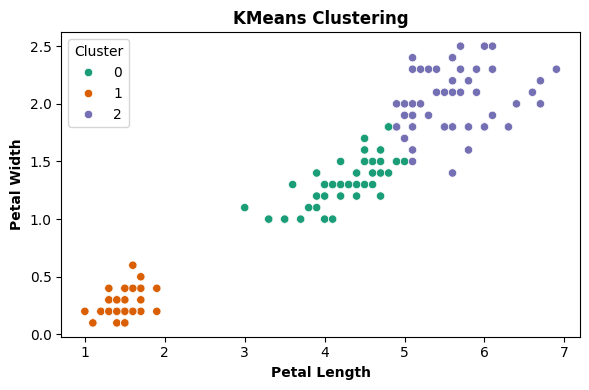

In [115]:
X_clust = df[['PetalLengthCm', 'PetalWidthCm']]

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_clust)

plt.figure(figsize=(6, 4))
sns.scatterplot(x='PetalLengthCm', y='PetalWidthCm', hue='Cluster', data=df, palette='Dark2')
plt.title('KMeans Clustering', fontweight='bold')
plt.xlabel('Petal Length', fontweight='bold')
plt.ylabel('Petal Width', fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_clustering.png')
plt.show()

Bu grafik, KMeans algoritmasıyla taç yaprağı uzunluğu ve genişliğine göre oluşturulan üç farklı grubu gösteriyor. Grup 0, en kısa taç yapraklarına sahip olup diğerlerinden tamamen ayrı duruyor. Grup 1 ve Grup 2 ise daha uzun taç yapraklarına sahip olsalar da, birbirlerinden genel olarak iyi ayrılmış durumdalar. Algoritma, çiçekleri boyutlarına göre başarılı şekilde kümelendirmiş.

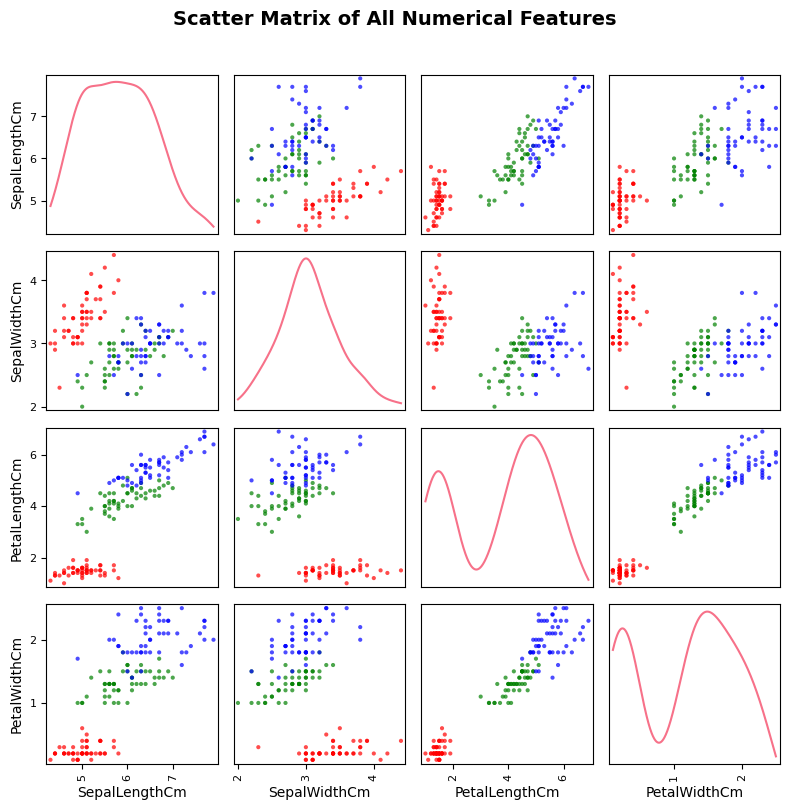

In [116]:
color_map = {'Iris-setosa': 'red', 'Iris-versicolor': 'green', 'Iris-virginica': 'blue'}
colors = df['Species'].map(color_map)

sm = scatter_matrix(
    df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']],
    figsize=(8, 8),
    diagonal='kde',
    color=colors,
    alpha=0.7
)

plt.suptitle('Scatter Matrix of All Numerical Features', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('scatter_matrix.png')
plt.show()

Bu grafik, tüm sayısal özelliklerin birbirleriyle ilişkilerini türlere göre gösteriyor. Kırmızı renkli Iris-setosa, tüm özellik çiftlerinde diğer türlerden açıkça ayrılıyor. Yeşil ve mavi renkli türler, çanak yaprağı özelliklerinde biraz örtüşüyor. Ancak özellikle taç yaprağı uzunluğu ve genişliğine bakıldığında bu iki tür de belirgin şekilde ayrışıyor. Bu görsel, türlerin farklı boyutlara sahip olduğunu vurguluyor.

In [117]:
X = df.drop(columns=['Id', 'Species'])
y = df['Species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

ID silip verileri test ve eğitim olarak ayırdık

In [118]:
ırıs = X_train.copy()

In [119]:
ırıs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120 entries, 8 to 3
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  120 non-null    float64
 1   SepalWidthCm   120 non-null    float64
 2   PetalLengthCm  120 non-null    float64
 3   PetalWidthCm   120 non-null    float64
 4   Cluster        120 non-null    int32  
dtypes: float64(4), int32(1)
memory usage: 5.2 KB


In [120]:
ırıs.nunique()

SepalLengthCm    33
SepalWidthCm     22
PetalLengthCm    40
PetalWidthCm     22
Cluster           3
dtype: int64

In [121]:
ırıs.isnull().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Cluster          0
dtype: int64

In [122]:
def iqr_summary(df):
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

    summary = []

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)][col]
        outlier_count = outliers.count()
        outlier_ratio = round((outlier_count / df.shape[0]) * 100, 2)

        summary.append({
            'Feature': col,
            'Min': df[col].min(),
            'Q1': Q1,
            'Q3': Q3,
            'Max': df[col].max(),
            'IQR': IQR,
            'Lower Bound': lower,
            'Upper Bound': upper,
            'Outlier Count': outlier_count,
            'Outlier Ratio (%)': outlier_ratio
        })

    return pd.DataFrame(summary)

iqr_table = iqr_summary(ırıs.drop(columns='Cluster'))
from IPython.display import display
display(iqr_table)

,Feature,Min,Q1,Q3,Max,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Ratio (%)
0,SepalLengthCm,4.3,5.1,6.4,7.9,1.3,3.15,8.35,0,0.00
1,SepalWidthCm,2.0,2.8,3.3,4.4,0.5,2.05,4.05,4,3.33
2,PetalLengthCm,1.1,1.6,5.1,6.9,3.5,-3.65,10.35,0,0.00
3,PetalWidthCm,0.1,0.3,1.8,2.5,1.5,-1.95,4.05,0,0.00


IQR rutin bir işlemim. Şu an sorun yok. Veri seti çok küçük sorun olmazdı zaten. Veriler değerli.

In [123]:
ırıs.drop(columns='Cluster', inplace=True)
X_test = X_test.drop(columns='Cluster')

Bu sütunu K-means için üretmiştik o yüzden modelleme öncesi işlevini tamamladığı için siliyoruz.

In [124]:
ırıs['SepalArea'] = ırıs['SepalLengthCm'] * ırıs['SepalWidthCm']
X_test['SepalArea'] = X_test['SepalLengthCm'] * X_test['SepalWidthCm']

Sepal uzunluğu ve genişliği çarpılarak çiçeğin dış yaprağının (sepal) alanı tahmini olarak üretildi. Farklı türler bu ölçüye göre farklılık gösterebilir. Bu, boyutsal farkları yakalamaya yardımcı olur.

In [125]:
ırıs['PetalArea'] = ırıs['PetalLengthCm'] * ırıs['PetalWidthCm']
X_test['PetalArea'] = X_test['PetalLengthCm'] * X_test['PetalWidthCm']

Aynı mantıkla, petal boyutları çarpılarak çiçeğin renkli iç yapraklarının yüzey alanı çıkarıldı. Petal ölçümleri türler arasında genelde en belirleyici faktördür, bu da doğrudan katkı sağlar.

In [126]:
ırıs['SepalPetalLengthRatio'] = ırıs['SepalLengthCm'] / ırıs['PetalLengthCm']
X_test['SepalPetalLengthRatio'] = X_test['SepalLengthCm'] / X_test['PetalLengthCm']

Burada oran hesaplandı. Özellikle PetalLengthCm kısa olan setosa gibi türlerde bu oran yüksektir. Bu da sınıflar arası yapısal ayrımı sezgisel olarak güçlendirir.

In [127]:
ırıs.dtypes

SepalLengthCm            float64
SepalWidthCm             float64
PetalLengthCm            float64
PetalWidthCm             float64
SepalArea                float64
PetalArea                float64
SepalPetalLengthRatio    float64
dtype: object

In [128]:
X_test.dtypes

SepalLengthCm            float64
SepalWidthCm             float64
PetalLengthCm            float64
PetalWidthCm             float64
SepalArea                float64
PetalArea                float64
SepalPetalLengthRatio    float64
dtype: object

Bunlar iyi hoş bir şey yapmayacağız. Scalling adımı için de bir şey uygulamak istemiyorum veriler zaten az ve IQR yok. Yanlış düşünüyorsam bile ileride doğrusunu öğrenirim zaten.

In [129]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [ ]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

log_model = LogisticRegression(max_iter=200) #lg
log_model.fit(ırıs, y_train_encoded)
log_preds = log_model.predict(X_test)
log_probs = log_model.predict_proba(X_test)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42) #rf
rf_model.fit(ırıs, y_train_encoded)
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)

xgb_model = XGBClassifier(eval_metric='mlogloss', random_state=42) #xg
xgb_model.fit(ırıs, y_train_encoded)
xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)

svc_model = SVC(probability=True) #svc
svc_model.fit(ırıs, y_train_encoded)
svc_preds = svc_model.predict(X_test)
svc_probs = svc_model.predict_proba(X_test)

In [131]:
results = []

models = {
    "Logistic Regression": log_preds,
    "Random Forest": rf_preds,
    "XGBoost": xgb_preds,
    "SVC": svc_preds
}

for name, preds in models.items():
    acc = accuracy_score(y_test_encoded, preds)
    prec = precision_score(y_test_encoded, preds, average='macro')
    rec = recall_score(y_test_encoded, preds, average='macro')
    f1 = f1_score(y_test_encoded, preds, average='macro')
    results.append([name, acc, prec, rec, f1])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0000,1.0000,1.0000,1.0000
1,Random Forest,0.9333,0.9333,0.9333,0.9333
2,XGBoost,0.9000,0.9024,0.9000,0.8997
3,SVC,0.9667,0.9697,0.9667,0.9666


LG overfit olmuş. Ölçeklendirme yapmamıştık ama buarada yapalım onu. Önce veri ölçekleme sonra hiperparametre optimizasyonu sonra çapraz doğrulama yapalım

In [132]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(ırıs)
X_test_scaled = scaler.transform(X_test)

StandardScaler ile sayıları aynı adil ölçeğe getirdik

In [133]:
params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

log_grid = GridSearchCV(LogisticRegression(max_iter=200), param_grid=params, cv=5, scoring='accuracy')
log_grid.fit(X_train_scaled, y_train_encoded)
best_log_model = log_grid.best_estimator_

GridSearchCV kullanarak model için en iyi ayarları bulduk. Tüm olası parametre kombinasyonlarını çapraz doğrulama ile denedik. Bu işlem, modelin en yüksek performansı verecek hiperparametreleri otomatik olarak belirlemesini sağladı.

In [134]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
log_cv_scores = cross_val_score(best_log_model, X_train_scaled, y_train_encoded, cv=cv, scoring='accuracy')
log_cv_scores.mean(), log_cv_scores.std()

(np.float64(0.9666666666666668), np.float64(0.031180478223116186))

Bulduğumuz en iyi modelin performansını StratifiedKFold ile değerlendirdik. cross_val_score kullanarak modelin doğruluk skorlarını aldık. Elde edilen ortalama ve standart sapma değerleri, modelin genel başarısını ve farklı veri parçaları üzerindeki tutarlılığını gösterdi.